In [11]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

## Load Data and prep features

In [3]:
df = pd.read_parquet('pm25_tcn.parquet')
df = df.sort_values(by=['site_id', 'datetime'])

FEATURE_COLS = [
    'pm_filled', 'wind_speed', 'wind_dir', 
    'smoke_prox_1', 'smoke_prox_2', 'smoke_prox_3',
    'fire_prox_1', 'fire_prox_2', 'fire_prox_3'
]
TARGET_COL = 'pm_filled'
SEQ_LEN = 24
HORIZON = 1

In [4]:
# Filter features
available_features = [c for c in FEATURE_COLS if c in df.columns]
target_idx = available_features.index(TARGET_COL)

# Split Train/Test
split_date = df['datetime'].quantile(0.8)
train_df = df[df['datetime'] < split_date].copy()
test_df = df[df['datetime'] >= split_date].copy()

# Scale
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df[available_features])
test_scaled = scaler.transform(test_df[available_features])

In [5]:
class AirQualityDataset(Dataset):
    def __init__(self, data, seq_len, horizon, target_idx):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.seq_len = seq_len
        self.horizon = horizon
        self.target_idx = target_idx
        
    def __len__(self):
        return len(self.data) - self.seq_len - self.horizon + 1
    
    def __getitem__(self, idx):
        # Input: (Seq_Len, Features) -> PyTorch expects (Features, Seq_Len) for Conv1d
        x = self.data[idx : idx + self.seq_len]
        x = x.transpose(0, 1) # Swap to (C, L) format
        
        # Output: Scalar value
        y = self.data[idx + self.seq_len + self.horizon - 1, self.target_idx]
        return x, y

# Create Loaders
train_dataset = AirQualityDataset(train_scaled, SEQ_LEN, HORIZON, target_idx)
test_dataset = AirQualityDataset(test_scaled, SEQ_LEN, HORIZON, target_idx)

# Batch size 64 is good for TCN
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## TCN Architecture

In [ ]:
class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation):
        super(CausalConv1d, self).__init__()
        # Padding calculation: (K-1) * D
        self.padding = (kernel_size - 1) * dilation
        
        self.conv = nn.Conv1d(
            in_channels, 
            out_channels, 
            kernel_size, 
            padding=self.padding, 
            dilation=dilation
        )
        
    def forward(self, x):
        x = self.conv(x)
        # Remove the padding from the right (future) side to maintain causality
        return x[:, :, :-self.padding]

class TCNModel(nn.Module):
    def __init__(self, num_inputs, num_channels=64, kernel_size=3, dropout=0.2):
        super(TCNModel, self).__init__()
        
        # Layer 1: Dilation 1 (Look at immediate past)
        self.tcn1 = CausalConv1d(num_inputs, num_channels, kernel_size, dilation=1)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)
        
        # Layer 2: Dilation 2 (Look 2 steps back)
        self.tcn2 = CausalConv1d(num_channels, num_channels, kernel_size, dilation=2)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)
        
        # Layer 3: Dilation 4 (Look 4 steps back)
        self.tcn3 = CausalConv1d(num_channels, num_channels, kernel_size, dilation=4)
        self.relu3 = nn.ReLU()
        self.drop3 = nn.Dropout(dropout)
        
        # Output Layer: Linear map to 1 predicted value
        self.linear = nn.Linear(num_channels, 1)
        
    def forward(self, x):
        # x shape: (Batch, Features, Seq_Len)
        
        y1 = self.drop1(self.relu1(self.tcn1(x)))
        y2 = self.drop2(self.relu2(self.tcn2(y1)))
        y3 = self.drop3(self.relu3(self.tcn3(y2)))
        
        # Take the LAST time step only (Predict based on full history)
        # shape becomes (Batch, Channels)
        last_step = y3[:, :, -1] 
        
        return self.linear(last_step)

# Initialize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TCNModel(num_inputs=len(available_features)).to(device)
# print(model)

TCNModel(
  (tcn1): CausalConv1d(
    (conv): Conv1d(9, 64, kernel_size=(3,), stride=(1,), padding=(2,))
  )
  (relu1): ReLU()
  (drop1): Dropout(p=0.2, inplace=False)
  (tcn2): CausalConv1d(
    (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
  )
  (relu2): ReLU()
  (drop2): Dropout(p=0.2, inplace=False)
  (tcn3): CausalConv1d(
    (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(4,))
  )
  (relu3): ReLU()
  (drop3): Dropout(p=0.2, inplace=False)
  (linear): Linear(in_features=64, out_features=1, bias=True)
)


## Training

In [14]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
num_epochs = 5
train_losses = []
test_losses = []

print("Starting Training...\n")

for epoch in range(num_epochs):
    
    # 1. TRAINING
    model.train()
    running_loss = 0.0
    
    # 'leave=False' means the bar disappears after the epoch finishes, 
    # leaving only your clean print statement behind. 
    # Change to True if you want to keep the bars.
    loop = tqdm(train_loader, total=len(train_loader), leave=True)
    loop.set_description(f"Epoch {epoch+1}/{num_epochs}")
    
    for X_batch, y_batch in loop:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Live update of the batch loss in the progress bar
        loop.set_postfix(loss=loss.item())
    
    # 2. VALIDATION
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_val, y_val in test_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            outputs = model(X_val).squeeze()
            loss = criterion(outputs, y_val)
            val_loss += loss.item()
            
    # 3. CALCULATE AVERAGES
    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_loss / len(test_loader)
    
    train_losses.append(avg_train_loss)
    test_losses.append(avg_val_loss)
    
    # 4. EXPLICIT PRINT (The Clean Log)
    # This prints the permanent record for the epoch
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}")

print("\nTraining Complete.")

Starting Training...



Epoch 1/5: 100%|██████████| 7277/7277 [01:54<00:00, 63.48it/s, loss=4.55e-5] 


Epoch 1/5 | Train Loss: 0.00006 | Val Loss: 0.00003


Epoch 2/5: 100%|██████████| 7277/7277 [01:54<00:00, 63.56it/s, loss=3.26e-5] 


Epoch 2/5 | Train Loss: 0.00006 | Val Loss: 0.00004


...

Epoch 3/5 | Train Loss: 0.00006 | Val Loss: 0.00004


Epoch 4/5: 100%|██████████| 7277/7277 [01:46<00:00, 68.52it/s, loss=1.63e-5] 


Epoch 4/5 | Train Loss: 0.00006 | Val Loss: 0.00003


Epoch 5/5: 100%|██████████| 7277/7277 [01:43<00:00, 70.33it/s, loss=6.07e-5] 


Epoch 5/5 | Train Loss: 0.00006 | Val Loss: 0.00004

Training Complete.


In [15]:
# 1. Get predictions
model.eval()
with torch.no_grad():
    # Grab a batch from the test loader
    X_test_batch, y_test_batch = next(iter(test_loader))
    X_test_batch = X_test_batch.to(device)
    
    # Predict
    y_pred_scaled = model(X_test_batch).squeeze().cpu().numpy()
    y_true_scaled = y_test_batch.cpu().numpy()

# 2. Inverse Transform (Back to Real Units)
# We need to reshape to match the original scaler's expected shape
def inverse_transform_target(y_scaled, scaler, target_idx, n_features):
    # Create a dummy matrix filled with zeros
    dummy = np.zeros((len(y_scaled), n_features))
    # Fill the target column
    dummy[:, target_idx] = y_scaled
    # Inverse transform
    return scaler.inverse_transform(dummy)[:, target_idx]

# Apply inverse transform
y_pred_real = inverse_transform_target(y_pred_scaled, scaler, target_idx, len(available_features))
y_true_real = inverse_transform_target(y_true_scaled, scaler, target_idx, len(available_features))

# 3. Calculate Real Error
real_mae = np.mean(np.abs(y_pred_real - y_true_real))
print(f"Scaled MSE Loss: {0.00004}")
print(f"Real World MAE:  {real_mae:.2f} µg/m³")

Scaled MSE Loss: 4e-05
Real World MAE:  2.60 µg/m³


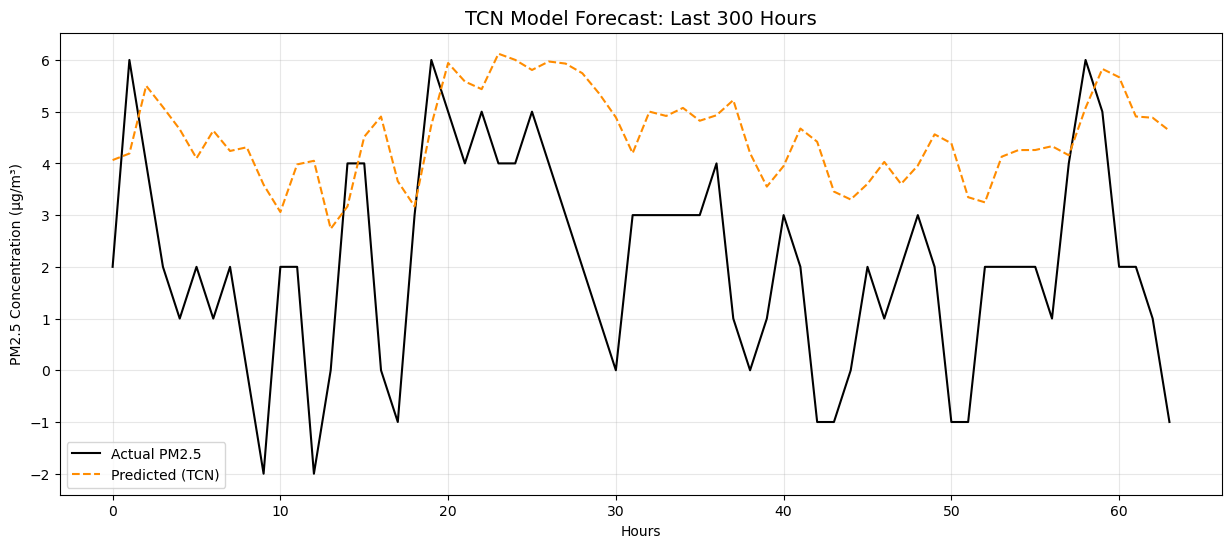

In [16]:
import matplotlib.pyplot as plt

# 1. Select a slice of data to visualize (e.g., last 300 hours of the test set)
# We use the 'y_true_real' and 'y_pred_real' you just calculated
start_idx = -300
end_idx = None # Go to the end

plt.figure(figsize=(15, 6))
plt.plot(y_true_real[start_idx:end_idx], label='Actual PM2.5', color='black', linewidth=1.5)
plt.plot(y_pred_real[start_idx:end_idx], label='Predicted (TCN)', color='#FF8C00', linestyle='--', linewidth=1.5)

plt.title('TCN Model Forecast: Last 300 Hours', fontsize=14)
plt.ylabel('PM2.5 Concentration (µg/m³)')
plt.xlabel('Hours')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
import numpy as np

# Define a threshold for "Smoke/Unhealthy" (EPA standard is 35)
smoke_threshold = 35

# Filter for rows where the ACTUAL value was high
mask = y_true_real >= smoke_threshold
high_pm_actual = y_true_real[mask]
high_pm_pred = y_pred_real[mask]

if len(high_pm_actual) > 0:
    smoke_mae = np.mean(np.abs(high_pm_actual - high_pm_pred))
    print(f"Standard MAE (All Data):  2.60 µg/m³")
    print(f"Smoke MAE (PM2.5 > {smoke_threshold}): {smoke_mae:.2f} µg/m³")
    
    # Optional: Scatter plot for high values
    plt.figure(figsize=(6, 6))
    plt.scatter(high_pm_actual, high_pm_pred, alpha=0.5, color='red')
    plt.plot([smoke_threshold, max(high_pm_actual)], [smoke_threshold, max(high_pm_actual)], 'k--') # Perfect prediction line
    plt.xlabel('Actual Smoke Levels')
    plt.ylabel('Predicted Smoke Levels')
    plt.title('Performance on Smoke Events Only')
    plt.show()
else:
    print("No smoke events (> 35) found in this test batch.")

No smoke events (> 35) found in this test batch.
